# Hands-On AI for Science
### Aug 14 Afternoon: Where Is Waldo? — Convolutional Neural Nets
### Written by Kamila Abdiyeva for CS 440/ECE 448

In this assignment, you will build a computer vision pipeline from scratch. Similar to the well-known puzzle "Where is Waldo?", we will search for specific patterns within an image. For this simplified version, we will focus on identifying blobs and bars rather than Waldo's canonical red-and-white stripes.

You will start by implementing the fundamental mathematics of convolution, apply those operations to detect geometric patterns, explore gradient-based edge detection, and finally "train" a filter to recognize patterns automatically using gradient descent.

INSTRUCTIONS
------------------------
1) Put ALL your solutions in `submitted.py`
2) Only edit code inside the marked `TODO` blocks.
3) Do NOT change function names, arguments, or return types.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple, Union

import numpy as np

import submitted
import get_data

import importlib
importlib.reload(submitted)
importlib.reload(get_data)

<module 'get_data' from '/Users/jhasegaw/Dropbox/mark/teaching/minicourse/2026/hands_on_ai_for_science/aug14/afternoon/mark/get_data.py'>


# 1. Fundamentals: Correlation vs. Convolution

When finding a match between a pattern (kernel) and an image, we use two primary operations. While they are similar, the distinction is crucial for formal signal processing.

## Understanding "Valid" Padding

In this assignment, we use "Valid" padding. This means:


*  No Padding: We do not add any extra zeros (or other values) around the edges of the input image.
*   Full Overlap: The kernel is only placed at positions where it fully overlaps with the original image. The kernel never "hangs over" the edge.

*  Dimension Reduction: Because the kernel cannot go outside the bounds, the resulting output (feature map) will be smaller than the input image.

The formula for the output size is:

$H_{out} = H_{in} - K_h + 1$

$W_{out} = W_{in} - K_w + 1$

## Required Functions in `submitted.py`

`correlation2d(image, kernel)`

* Implement 2D cross-correlation using "Valid" padding.

* Slide the kernel across the image.

* Multiply overlapping values and sum them.

* Stride: Always use 1.

* Output Dimensions: Use the "Valid" padding formula mentioned above.

`convolve2d(image, kernel)`

Implement 2D convolution.

* Mathematically: You must flip the kernel 180 degrees (both horizontally and vertically) before performing the sliding sum.

* Tip: You can implement this by flipping the kernel and then calling your correlation2d function.

**Note:** In many deep learning libraries (like PyTorch or TensorFlow), the "convolution" layer actually implements cross-correlation for efficiency, as the network simply learns the "flipped" weights anyway.

However, for this assignment, we will implement the mathematically formal version.

**TODO**: Implement `convolve2d, correlation2d` in `submitted.py`

In [2]:
importlib.reload(submitted)
importlib.reload(get_data)

from submitted import convolve2d, correlation2d
import numpy as np

# Define a simple 3x3 input image
input_image = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Define a simple 2x2 asymmetric kernel
# Using an asymmetric kernel ensures convolution (flipped) and correlation are different
kernel = np.array([
    [1, 0],
    [0, -1]
])

print("Input Image:\n", input_image)
print("Kernel:\n", kernel)

# Perform cross-correlation
corr_output = correlation2d(input_image, kernel)
print("\nCross-Correlation Output:\n", corr_output)

# Perform convolution
conv_output = convolve2d(input_image, kernel)
print("\nConvolution Output:\n", conv_output)

# Verify that the outputs are different
if not np.allclose(corr_output, conv_output):
    print("\nSUCCESS: Convolution and Cross-Correlation produced different results for an asymmetric kernel.")
else:
    print("\nWARNING: Convolution and Cross-Correlation produced the same results!")

Input Image:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Kernel:
 [[ 1  0]
 [ 0 -1]]


NotImplementedError: 

# 2. Synthetic Pattern Detection

Computers "see" features by scanning for regions with high mathematical response to specific kernels. You will implement detectors for two geometric shapes: Blobs and Bars.

## Required Functions in `submitted.py`

`detect_blob(image, k=5)`

* Construct a circular kernel of size $k \times k$ (where $k$ is odd). You can assume that circule radius = k//2.

* The kernel should be a binary circle mask (1.0 inside, 0.0 outside) normalized so that the sum of all weights equals 1.0.

* Perform convolution and return the kernel and the coordinates of the global maxima.

`detect_bar(image, k=7)`

* Construct a vertical bar kernel of size $k \times k$.

* The kernel should have a vertical line of 1.0s in the center column, normalized to sum to 1.0.

* Return the kernel and the detected positions of the global maxima.

`def detect_positions(image):`
use in `detect_bar` and `detect_blob` to return the coordinates of global maxima.

**Evaluation:**
Your detection is considered successful if the returned coordinates are within a small radius of the ground-truth locations used to generate the synthetic image.

**Hint:** The `detect_*` function should perform convolution with constructed gradient kernel using `convolve2d`, then find the global maxima using `detect_positions`, and finally return both the kernel and the detected positions

Convolution or detection functions not yet implemented or error: 


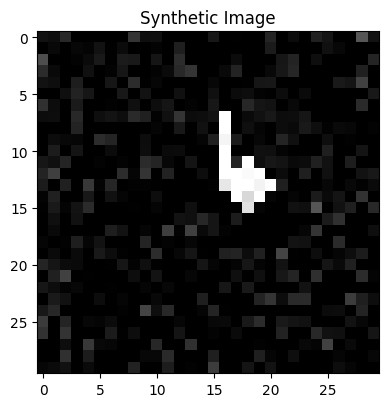

{'blob': {'total': 1, 'detected': 0}, 'bar': {'total': 1, 'detected': 0}}


In [3]:
importlib.reload(submitted)
importlib.reload(get_data)

import numpy as np
import matplotlib.pyplot as plt

from submitted import convolve2d, detect_blob, detect_bar, detect_positions
from get_data import generate_synthetic_data, qualitative_check


if __name__ == "__main__":
    # 1. Generate Data
    img, gt = generate_synthetic_data(num_shapes=2)

    # 2. Run Detectors
    # blob_k = detect_blob()
    # bar_k = detect_bar()

    # Example visualization
    plt.figure(figsize=(15, 5))
    plt.subplot(131)
    plt.title("Synthetic Image")
    plt.imshow(img, cmap='gray')

    # Initialize blob_pos and bar_pos to empty arrays or None
    # to handle cases where detection fails or isn't implemented
    blob_pos = np.array([])
    bar_pos = np.array([])

    try:
        # Detect Blobs
        blob_k, blob_pos = detect_blob(img)
        blob_map = convolve2d(img, blob_k)
        # blob_pos = detect_positions(blob_map)

        plt.subplot(132)
        plt.title("Blob Detections")
        plt.imshow(blob_map, cmap='hot')
        if len(blob_pos) > 0:
             # Scatter takes (x, y), numpy is (row, col) -> (y, x)
             plt.scatter(blob_pos[:, 1], blob_pos[:, 0], edgecolors='cyan', facecolors='none', s=80, label='Blob Matches')
             plt.legend()

        # Detect Bars
        bar_k, bar_pos = detect_bar(img)
        bar_map = convolve2d(img, bar_k)

        plt.subplot(133)
        plt.title("Bar Detections")
        plt.imshow(bar_map, cmap='hot')
        if len(bar_pos) > 0:
             plt.scatter(bar_pos[:, 1], bar_pos[:, 0], edgecolors='lime', facecolors='none', marker='s', s=80, label='Bar Matches')
             plt.legend()

    except Exception as e:
        print(f"Convolution or detection functions not yet implemented or error: {e}")

    plt.show()

    # Visualize Kernels
    if 'blob_k' in locals() and 'bar_k' in locals():
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.title("Blob Kernel")
        plt.imshow(blob_k, cmap='gray')
        plt.colorbar()

        plt.subplot(1, 2, 2)
        plt.title("Bar Kernel")
        plt.imshow(bar_k, cmap='gray')
        plt.colorbar()
        plt.show()

    # Call the qualitative check function
    results = qualitative_check(gt, blob_pos, bar_pos)
    print(results)

# 3. Gradient-Based Edge/Bar Detection

Gradient filters measure the rate of change in pixel intensities. This allows us to find edges even when the shapes aren't perfectly uniform.

Two most popular in this cathegory are Sobel and Prewitt. The main difference between these filters is the weight assigned to the central row (for horizontal gradient) or column (for vertical gradient):

* Prewitt Operator: Uses uniform weights.

* Sobel Operator: Assigns a higher weight to the center pixel to provide better smoothing and reduce noise sensitivity.

To start, we will use a simpler, generic gradient example.
Assume we have 3x3 **Vertical Gradient Kernel (Prewitt)**:

        [-1, -1, -1]
        [ 0,  0,  0]
        [ 1,  1,  1]

Replacing the middle -1 and 1 with *-scale* and *scale* (where *scale=2*) would transform this into a Sobel-like filter

        [-1, -2, -1]
        [ 0,  0,  0]
        [ 1,  2,  1]

In your `detect_bar_gradient` you need to implement **3x3 Horizontal Gradient** Kernel, with scalar *scale* for the central pixels.


`detect_bar_gradient(image, scale=2)`

* Implement a 3x3 Horizontal Gradient Filter.

* Use scalar *scale* for the central pixel  When *scale=1*, this is a Prewitt filter. When *scale=2*, it is a Sobel filter.

* Return the kernel and the detected coordinates of the highest gradient. The `detect_bar_gradient` function should perform convolution with constructed gradient kernel using `convolve2d`, then find the global maxima using `detect_positions`, and finally return both the kernel and the detected positions


Convolution or detection functions not yet implemented or error: 


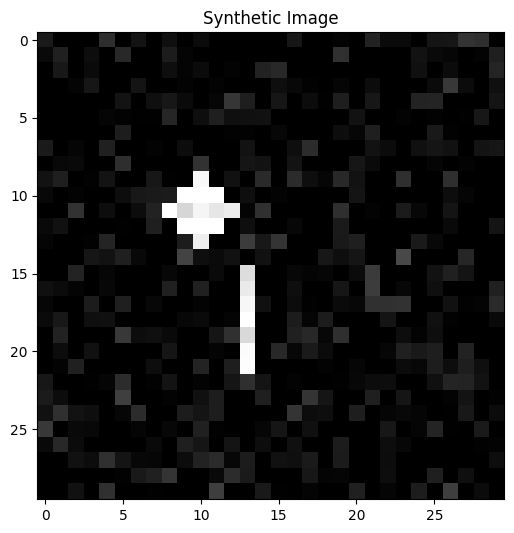

{'blob': {'total': 1, 'detected': 0}, 'bar': {'total': 1, 'detected': 0}}


In [4]:
import submitted
import get_data

import importlib
importlib.reload(submitted)
importlib.reload(get_data)

import numpy as np
import matplotlib.pyplot as plt

from submitted import convolve2d, detect_bar_gradient
from get_data import generate_synthetic_data, qualitative_check


if __name__ == "__main__":
    # 1. Generate Data
    img, gt = generate_synthetic_data(num_shapes=2)

    # Initialize positions to empty arrays to prevent NameError
    bar_pos = np.array([])

    # Example visualization
    plt.figure(figsize=(15, 5))

    # Subplot 1: Original Image
    plt.subplot(131)
    plt.title("Synthetic Image")
    plt.imshow(img, cmap='gray')

    try:
        # Detect Bars
        bar_k, bar_pos = detect_bar_gradient(img)
        bar_map = convolve2d(img, bar_k)

        # Subplot 2: Bar Kernel
        plt.subplot(132)
        plt.title("Bar Gradient Kernel")
        plt.imshow(bar_k, cmap='gray')
        plt.colorbar()

        # Subplot 3: Bar Detections
        plt.subplot(133)
        plt.title("Bar Detections")
        plt.imshow(bar_map, cmap='hot')
        if len(bar_pos) > 0:
             plt.scatter(bar_pos[:, 1], bar_pos[:, 0], edgecolors='lime', facecolors='none', marker='s', s=80, label='Bar Matches')
             plt.legend()

    except Exception as e:
        print(f"Convolution or detection functions not yet implemented or error: {e}")

    plt.tight_layout()
    plt.show()

    # Call the qualitative check function
    results = qualitative_check(gt, blob_pos, bar_pos)
    print(results)

# 4. Learning Filters for Recognition

In the previous sections, you manually engineered kernels to detect specific features like blobs, bars, and gradients. This process is known as feature engineering and was the standard in computer vision for decades.
Modern AI doesn't rely on human-designed filters. Instead, kernels are "learned" from data. You will implement a simplified training loop to find a $3 \times 3$ kernel that can distinguish a Blob (Label 1) from a Bar (Label 0).

`train_classifier(images, labels, epochs=100)`

* Optimize a $3 \times 3$ kernel $K$ using Stochastic Gradient Descent (SGD). SGD is an optimization algorithm that iteratively updates model parameters (weights) by calculating the gradient of the loss function for **a single training example** at a time:

* Initialize: Start with a 3x3 kernel of small random values.

* Forward Pass: Convolve the image (using `convolve2d`) and the peak response (max).

* Loss: Use Mean Squared Error (MSE): $L = (max - y)^2$

  $y = 1.0$ if the image contains a blob.

  $y = 0.0$ if the image contains a bar.

* Backprop: Calculate the gradient of the loss with respect to the kernel weights.

  Multi-Max Handling: If multiple locations share the exact same maximum response, average their gradients to update the kernel.

* Update: $K = K - (lr \times gradient)$

* Adjust hyperparameter $lr$ (learning rate) to achieve the best performance.

  Learning Rate ($lr$): A hyperparameter that controls how much to change the model in response to the estimated error each time the model weights are updated.

  If $lr$ is too small, training will take a very long time to converge.

  If $lr$ is too large, it may cause the weights to oscillate wildly or even diverge.

* Dataset Setup: Use the provided synthetic generator in `get_data.py` to create a balanced set of blob and bar images.

`predict(image, kernel, threshold=0.5):`

*   perform convolution with learned kernel using `convolve2d`
*   find the global maxima
*   return  global maxima > threshold, global maxima



### To think about

 - Interpretability: After training, what does your learned kernel look like? Does it resemble the manual blob/bar kernels you designed in Q2?


**You need to achieve accuracy higher than 85% to pass the autograder**

**Before submitting** Run `python grade.py` to verify that your code passes all visible tests.

Generating dataset...


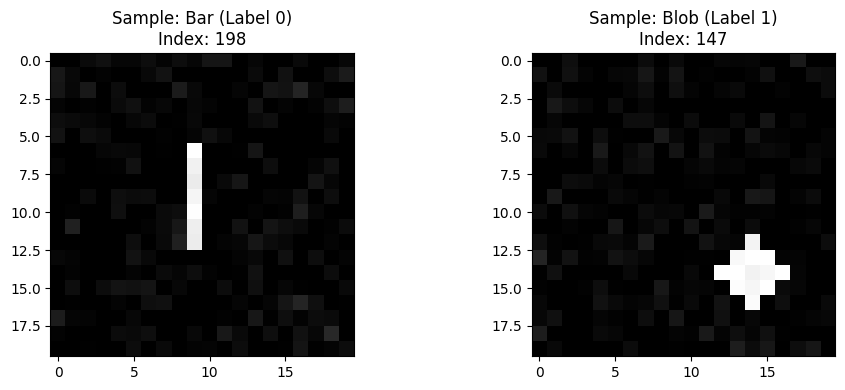

Training...


NotImplementedError: 

In [5]:
import submitted
import get_data

import importlib
importlib.reload(submitted)
importlib.reload(get_data)

from submitted import convolve2d, train_classifier, predict
from get_data import generate_data

import numpy as np
import matplotlib.pyplot as plt


# 1. Generate a synthetic dataset of blobs and bars
print("Generating dataset...")
X, y = generate_data(200)

plt.figure(figsize=(10, 4))

# Find a sample for 'bar' (Label 0)
bar_indices = np.where(y == 0.0)[0]
if len(bar_indices) > 0:
    idx_bar = np.random.choice(bar_indices)
    plt.subplot(1, 2, 1)
    plt.imshow(X[idx_bar], cmap='gray')
    plt.title(f"Sample: Bar (Label 0)\nIndex: {idx_bar}")

# Find a sample for 'blob' (Label 1)
blob_indices = np.where(y == 1.0)[0]
if len(blob_indices) > 0:
    idx_blob = np.random.choice(blob_indices)
    plt.subplot(1, 2, 2)
    plt.imshow(X[idx_blob], cmap='gray')
    plt.title(f"Sample: Blob (Label 1)\nIndex: {idx_blob}")

plt.tight_layout()
plt.show()

# 2. Split into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 3. Call train_classifier
print("Training...")
learned_filter = train_classifier(X_train, y_train, epochs=2, lr=0.1)

# 4. Evaluate and visualize the learned kernel
correct = 0
predictions = []
responses = []
for i in range(len(X_test)):
    is_blob, resp = predict(X_test[i], learned_filter, threshold=0.5)
    pred_label = 1.0 if is_blob else 0.0
    predictions.append(pred_label)
    responses.append(resp)
    if pred_label == y_test[i]:
        correct += 1

print(f"\nFinal Test Accuracy: {correct/len(X_test) * 100:.2f}%")

# Visualize Predictions on random test samples
plt.figure(figsize=(12, 6))
plt.suptitle("Test Set Predictions", fontsize=16)
sample_indices = np.random.choice(len(X_test), 8, replace=False)

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[idx], cmap='gray')

    gt = int(y_test[idx])
    pred = int(predictions[idx])
    conf = responses[idx]

    # Green if correct, Red if wrong
    color = 'green' if gt == pred else 'red'
    label_names = {0: "Bar", 1: "Blob"}

    plt.title(f"GT: {label_names[gt]}\nPred: {label_names[pred]}\nScore: {conf:.2f}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.title("Learned 3x3 Filter Weights")
plt.imshow(learned_filter, cmap='gray', interpolation='nearest')
plt.colorbar(label='Weight Intensity')
plt.show()